# Matplotlib - Format Charts
___
- EG: `fig, ax = plt.subplots()`
- We have Analyzed the Top Skills for Data Scientist, Engineer and Analyst but now, it's time to Compare the Values across all these Jobs!
- Problem is, they are all on separate Plots... so how do we do this?
    - Well convieniently, the `pyplot` Module from Matplotlib offers a `subplots()` Function
        - This lets us Graph everything on **one single figure**
- Best way to understand this, is to go to the [Cheetsheet](https://matplotlib.org/cheatsheets/)
    - Looking at the section called **Subplots Layout** there's a Function called `plt.subplots()`
        - With this Function, we can specify, the Rows and Columns for the Number of Axes on the Figure itself.
        - Running this Function specifying a 3 x 3. Returned are 2 Objects, a **tuple**, a `fig` and an `axs`
        - **Note**: An `axs` Object is each of the individual Plots (squares on the Diagram) on this `fig`

In [3]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

- For our first attempt, we are going to Create a Subplot on a 1x1 Figure
    - It provides 2 Objects
        - `fig`
        - `ax`
    - The standard nomanclature for this is: `fig, ax = `
    - **Note**: This can be named anything as desired... but it's very common to use `fig` and `ax`
    - Then Calling out the `plt` Module, specifically the `.subplots()` Function
    - Running it to make sure it works and to make sure the correct Method was Invoked

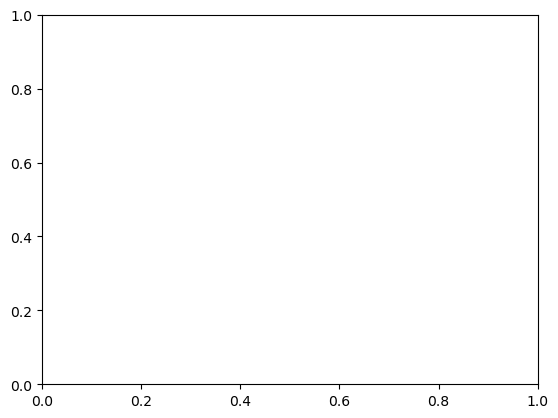

In [4]:
# Creating a simple Subplot on a 1x1 Figure using .subplot() Function
fig, ax = plt.subplots()

- As we can see from above, a basic Graph has been Plotted
- Adding in the Arguments for the **rows** and **columns** into the `.subplots()` Function, will Yield a Subplot Area with the specified Values
    - EG: Providing 2 for both the Rows and Columns will give a 2x2 Subplot Area

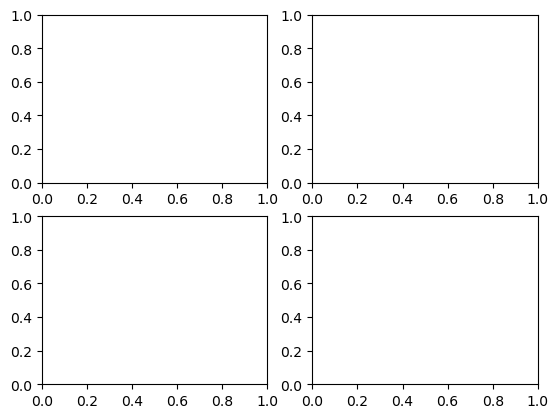

In [5]:
# Making a 2x2 Subplot Area
fig, ax = plt.subplots(2, 2)

- Keeping it simple for now, we will just work off of a 1x1 so we get to grips with how `subplots()` work
- Let's Plot, the **Counts** of the `job_title_short` Column
    - As always, using `.value_counts()` on the `df[job_title_short]` Column to get the Counts
    - Then using the `.plot()` Method alongside this, Plotting the Results on a bar chart, using `kind='bar'`
- Running this, we have what we want

<Axes: xlabel='job_title_short'>

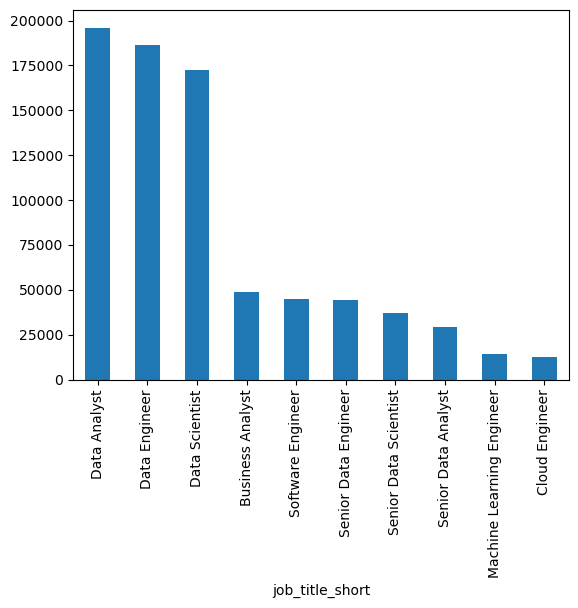

In [ ]:
# Plotting the Counts of the job_title_short Column in a bar chart
df['job_title_short'].value_counts().plot(kind='bar')

- Using the Plot that above, it's time to start using the `ax`
- To do this, we can Pass in the `ax` inside the `.plot()` Method, alongside the `kind`
    - This is the **Axis** for the **Figure** itself
- To do this, all that's needed is like so: `.plot(kind='bar', ax=ax)`
    - Specify `ax=` and then make it Equal to `ax`(This one was the one specified alongside the `fig` when making the Subplot)
    - Adding that in and Running it, will not change anything, it's still going to be the same Count Values of the different Job Titles

<Axes: xlabel='job_title_short'>

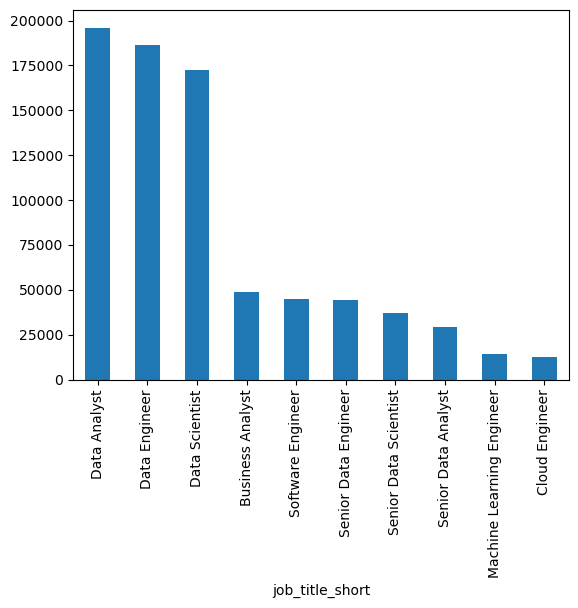

In [12]:
# Using the ax variable we specified in the Subplot, and making it equal the Plot with the Job Title Counts

# Creating the Basic Subplot again
fig, ax = plt.subplots()

# Making the Bar Chart for the Counts of job_title_shorts but including the ax Variable
df['job_title_short'].value_counts().plot(kind='bar', ax=ax)

- Now it's time to start Plotting 2 Plots!
- For that we will ofc, need a Second Plot
    - For the first one, it will be the Value Counts of the different `job_title_short` (The one made above)
    - The second one will be, a Value Count on the `job_schedule_type` but only looking at the first 3 Values
- Then we will need to get both of these Plots, into separate Bar Charts and then Add them on the same Figure (`fig`)
- Let's Set up the Data and get what we need so we can start Plotting them
    - To get the Data for the First Plot:
        - Do a `.value_counts()` on the `job_title_short`
    - To get the Data for the Second Plot:
        - Do a `.value_counts()` on the `job_schedule_type`
        - To get the Top 3, using `.head(3)` 

In [13]:
# Getting the value_counts for job_title_short
df['job_title_short'].value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [14]:
# Getting the value_counts for job_schedule_type and only Returning the Top 3 back
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

- Now, to Plot these, make them into Seperate Bar Charts and put them on the same Figure (`fig`)
    - Starting off specifying `fig` and `ax`
    - Making them equal to, `plt.subplots()`
    - Here, we pass in a Numerical Value for the **rows** (How many Lines of Graphs we want on the Figure)
        - In this case, it's 1 (since we only has 2 Graphs to Compare and want them side by side, not on top of each other)
    - Then, we pass in a Numerical Value for the **columns** (How many Graphs we want side by side on the Figure)
        - In this case, it's 2 (since we want to Compare 2 Graphs against each other)
    - Then, we Grab what we Created above and Paste it below the `.subplots()` Line (Grab the Code for Counts of `job_titles` and Counts of the Top 3 `job_schedule_type`)
        - Then Plotting both on separate Bar Charts, using `.plot(kind='bar')`
        - Don't forget to pass in the `ax=` inside the Plot Method on both as well, and Set it Equal to `ax`

AttributeError: 'numpy.ndarray' object has no attribute 'get_figure'

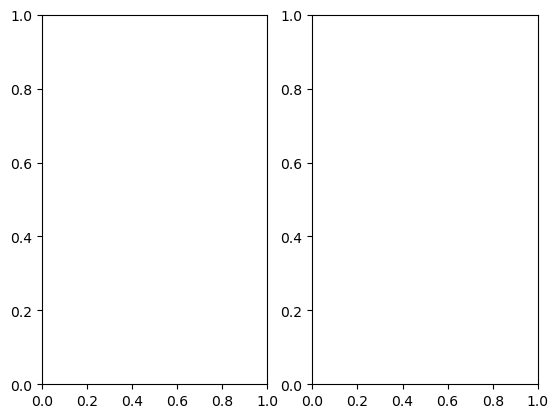

In [17]:
# Creating our Subplot with 1 Row and 2 Columns
fig, ax = plt.subplots(1, 2)

# Plotting our value_counts Data in separate Bar Charts for both the job_counts and job_schedule_type and specifying the ax Values as well
df['job_title_short'].value_counts().plot(kind='bar', ax=ax)
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax)

- Passing both of the `ax` Values here equals to the same Value will produce an Error
- Running the above, an Error occurrs as expected
    - Reason is: We need to Specify the **Index** of the `ax` that is being used
    - This is similar to a List, when Passing in an **Index**, square bracket notation is used `[]`
    - Following the sequence for **Indexes**, we start at 0 and end at 9.
        - First Plot will be Index[0] - `ax=ax[0]`
        - Second Plot will be Index[1] - `ax=ax[1]`

Text(0, 0.5, '')

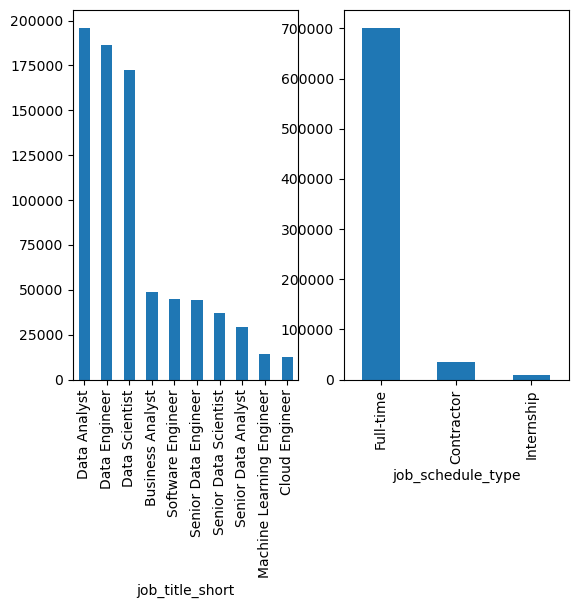

In [ ]:
# Setting the Indexes for the Individual Plots to place them on the subplots
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])


- We get back the 2 Bar Charts, side by side on the same Figure so we can compare them
    - Count of the `job_title_short` on the Left
    - Count of the `job_schedule_type` on the Right
- To switch them around, all that's needed is to trade/swap the Indexes
    - If you want to have the `job_schedule_type` on the Left and the `job_title_short` on the Right:
        - Specify `ax=ax[1]` for `job_title_short`
        - Specify `ax=ax[0]` for `job_schedule_type`
- As seen above, there is Overlap appearing... with the X Axis Values, spilling into the Chart on the Left...